# Are you a boy or a girl??
by George Ke, 2018

In this short demo, we are going to "predict" whether someone is a boy (male) or a girl (female) using some machine learning techniques.
We have been collecting data off real users by asking them to fill in a form in which some questions are legitmate while others are somewhat random. So, in this demo, we will:


1.   Load previously collected data as training data.
2.   Split the training data into a "training set" and a "validation set".
3.   Explore the training set
4.   Train some ML models on the training set
5.   Validate the effectiveness of the ML models on the validation set.
6.   Load "real" data we just collected to test the ML models. (optional)
7.   Plot some nice looking diagrams :)






# 1.   Load previously collected data as training data.
Let's up load the "previously collected" data into Colab.

In [2]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import io

# read in csv file from computer
#from google.colab import files
#uploaded = files.upload()

In [3]:
# read csv file from google drive in colab
# ref: http://nali.org/load-google-drive-csv-panda-dataframe-google-colab/

# The code installs PyDrive which will be used to access Google Drive and
#    kicks off the process to authorize the notebook running in the Google Colaboratory environment to touch your files.
# When it runs, you will be presented with a link to click on, which asks to verify Google Colab can have access to Google Drive and unique key.
# Enter the key back in the notebook.

!pip install -U -q PyDrive

^C


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orange3-explain 0.6.11 requires numpy>=2.0.0, but you have numpy 1.24.4 which is incompatible.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.24.4 which is incompatible.
tensorflow-intel 2.12.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.


In [ ]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# 1. Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# This code assumes your CSV files are in a folder. It will print out the files in a folder and their unique identifiers which will be used below.
# Replace <FOLDER ID> with the long string of numbers and letters in the URL of the folder in Google Drive.
# If the files are located at the top level of Google Drive, replace <FOLDER ID> with ‘root’.

file_list = drive.ListFile({'q': "'1Cymb_vR18AG7CKBDFIsxAfLIJmSmGHe-' in parents and trashed=false"}).GetList()
for file1 in file_list:
  print('title: %s, id: %s' % (file1['title'], file1['id']))

title: Boy_or_girl_test v2103.csv, id: 1tPT382WQEdzMyC7DG0RZr86W0bcCeCNO
title: Boy_or_girl_test.csv, id: 1GlmlYf4d3Pfo0lUlCofflcypcMHu-926
title: Boy_or_girl_test v1.csv, id: 1YkXNK03gvuWh-RME41JKKwWJqiOBsgJ2
title: Boy_or_girl_train.csv, id: 1KM40a-hg3Kiddlk9N4GUu3JDt_RyKJOv
title: Boy_or_girl_train_orig1.csv, id: 1kFY8Dj4llCFOJvAddHCGvv3O-AK_zryW
title: blogfeedback, id: 1gxZbo_5usswo4BfzqD_6NImOm2U6US7q
title: 1072_boy_or_girl.csv, id: 1stiJpFosIvENPuyMUam3XgXWh8D1TgOj
title: QuickML_EMBA_data.csv, id: 1vZy111S4ANQmw9e-hlnamZ8IVeLBcu2y
title: NCUIM_boy_girl2.csv, id: 1EsSyF2VD7sKHTVbrDqwdAFPMHrHn2dFp
title: NCUIM_boy_girl.csv, id: 1D_GJ0P2nlfuBp6guZ74oWoN6ux9Zmt3m
title: QuickML_data_utf8a.csv, id: 1APVwMS4XaD1zVP1hykMDbr6EESNvaWuP
title: QuickML_data_utf8.csv, id: 1DyfIv4oQRYUAOBoaprMDu4I9zLkKVFzu


In [ ]:
csv_from_gdrive = drive.CreateFile({'id': '1kFY8Dj4llCFOJvAddHCGvv3O-AK_zryW'})
csv_from_gdrive.GetContentFile('data.csv')

In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
# ref: https://www.kdnuggets.com/2018/02/essential-google-colaboratory-tips-tricks.html
# read in the csv file with UTF-8 encoding
#df = pd.read_csv(io.StringIO(uploaded['QuickML_data_utf8a.csv'].decode('utf-8')))

In [ ]:
# show the first 10 rows of the data
df[0:10]

,id,timestamp,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
0,1,4/7/2017 13:47,2,處女座,Apple,154.0,43.0,2,180.0,583.0,0,Beautiful
1,2,4/7/2017 13:48,2,處女座,Apple,156.0,47.0,2,130.0,400.0,3.5,Enjoying being who I'm notsss
2,3,4/7/2017 13:49,1,射手座,Android,170.0,61.0,3,90.0,540.0,5,Practice Makes perfect
3,4,4/7/2017 13:49,1,射手座,Apple,170.0,62.0,4,100.0,173.0,5,Straightforward
4,5,4/7/2017 13:54,2,射手座,Android,158.0,67.0,3,128.0,320.0,1.2,Humorous
5,6,4/7/2017 13:55,2,摩羯座,Android,158.0,50.0,3,100.0,903.0,2,I am cute
6,7,4/7/2017 13:56,1,天秤座,Android,165.0,50.0,4,115.0,209.0,9.59,Homo sapiens
7,8,4/7/2017 13:56,2,雙子座,Android,170.0,57.0,4,100.0,1200.0,NaN,Um..Haha
8,9,4/7/2017 13:57,2,射手座,Android,168.0,52.0,2,100.0,580.0,5.34,I am quite.
9,10,4/7/2017 14:00,2,牡羊座,Apple,165.0,55.0,5,130.0,542.0,2,Beautiful


So now lets encode the star signs so that "水瓶座" = '1', "雙魚座" = '2' and so on.

In [ ]:
# lowercase string
df['phone_os'] = df['phone_os'].str.lower()
# removing leading and trailing whitespaces
df['phone_os'] = df['phone_os'].str.strip()

coded_star_signs = {'水瓶座':1, '雙魚座':2, '牡羊座':3, '金牛座':4, '雙子座':5, '巨蟹座':6, '獅子座':7, '處女座':8, '天秤座':9, '天蠍座':10, '射手座':11, '摩羯座':12}
coded_phone_os = {'apple':1, 'android':2, 'windows phone':3, 'johncena':4}
coded_gender = {2:-1} #girls as -1

coded_df = df.replace({"star_sign": coded_star_signs})
coded_df = coded_df.replace({"phone_os": coded_phone_os})
coded_df = coded_df.replace({"gender": coded_gender})

coded_df[0:10]

,id,timestamp,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
0,1,4/7/2017 13:47,-1,8,1,154.0,43.0,2,180.0,583.0,0,Beautiful
1,2,4/7/2017 13:48,-1,8,1,156.0,47.0,2,130.0,400.0,3.5,Enjoying being who I'm notsss
2,3,4/7/2017 13:49,1,11,2,170.0,61.0,3,90.0,540.0,5,Practice Makes perfect
3,4,4/7/2017 13:49,1,11,1,170.0,62.0,4,100.0,173.0,5,Straightforward
4,5,4/7/2017 13:54,-1,11,2,158.0,67.0,3,128.0,320.0,1.2,Humorous
5,6,4/7/2017 13:55,-1,12,2,158.0,50.0,3,100.0,903.0,2,I am cute
6,7,4/7/2017 13:56,1,9,2,165.0,50.0,4,115.0,209.0,9.59,Homo sapiens
7,8,4/7/2017 13:56,-1,5,2,170.0,57.0,4,100.0,1200.0,NaN,Um..Haha
8,9,4/7/2017 13:57,-1,11,2,168.0,52.0,2,100.0,580.0,5.34,I am quite.
9,10,4/7/2017 14:00,-1,3,1,165.0,55.0,5,130.0,542.0,2,Beautiful


Next we want to deal with missing values. For example, let's look at the row with id 8 (index 7). The yt column for this row has 'NaN' as value, which indicates the value is missing. There are several approaches that help us deal with missing values. For references, please check out items 1-3 in the References & Resources section below.

In [ ]:
#check which columns have NaN in them
coded_df.isnull().any()

id            False
timestamp     False
gender        False
star_sign     False
phone_os      False
height        False
weight        False
sleepiness    False
iq             True
fb_friends    False
yt             True
self_intro    False
dtype: bool

In [ ]:
#show rows where yt field is NaN
coded_df[coded_df['yt'].isnull()]



,id,timestamp,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
7,8,4/7/2017 13:56,-1,5,2,170.0,57.0,4,100.0,1200.0,NaN,Um..Haha
22,23,4/7/2017 13:56,-1,5,2,170.0,57.0,4,100.0,1200.0,NaN,Um..Haha


In [ ]:
#show rows where iq field is NaN
coded_df[coded_df['iq'].isnull()]

,id,timestamp,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
20,21,4/7/2017 13:55,-1,12,2,158.0,50.0,3,NaN,903.0,2,I am cute
23,24,4/7/2017 13:57,-1,11,2,168.0,52.0,2,NaN,580.0,5.34,I am quite.


In [ ]:
#coded_df[(coded_df>0).all(1)]

In [ ]:
# lets clean up the codes
# ref: https://www.python-course.eu/lambda.php, http://book.pythontips.com/en/latest/lambdas.html
nan_rows = lambda df: df[df.isnull().any(axis=1)]
nan_rows(coded_df)


,id,timestamp,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
7,8,4/7/2017 13:56,-1,5,2,170.0,57.0,4,100.0,1200.0,NaN,Um..Haha
20,21,4/7/2017 13:55,-1,12,2,158.0,50.0,3,NaN,903.0,2,I am cute
22,23,4/7/2017 13:56,-1,5,2,170.0,57.0,4,100.0,1200.0,NaN,Um..Haha
23,24,4/7/2017 13:57,-1,11,2,168.0,52.0,2,NaN,580.0,5.34,I am quite.


So we have identified the rows with NaN values, let's discard them to keep the process simple here. Discarding records with missing values is not an uncommon practice when dealing missing values.

In [ ]:
cleaned_df = coded_df.dropna()

In [ ]:
cleaned_df = cleaned_df[(cleaned_df['height']<200) & (cleaned_df['height']>140) & (cleaned_df['weight']<200) & (cleaned_df['height']>100) & (cleaned_df['fb_friends']<=5000)]

In [ ]:
cleaned_df.describe()

,id,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends
count,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000,444.000000
mean,242.792793,0.495495,6.515766,1.545045,170.346779,64.387095,3.409910,125.538288,500.621622
std,138.624059,0.869590,3.479346,0.498529,8.118840,14.430934,1.191956,36.492875,480.195794
min,1.000000,-1.000000,1.000000,1.000000,147.000000,7.000000,1.000000,50.000000,0.000000
25%,123.750000,-1.000000,3.000000,1.000000,165.000000,55.000000,3.000000,100.000000,200.000000
50%,238.500000,1.000000,7.000000,2.000000,171.000000,63.000000,3.000000,120.000000,400.000000
75%,364.250000,1.000000,9.000000,2.000000,176.000000,71.250000,4.000000,145.250000,626.750000
max,481.000000,1.000000,12.000000,2.000000,190.000000,187.000000,5.000000,200.000000,5000.000000


In [ ]:
#cleaned_df.plot.scatter(x='weight',y='height',c='gender')

# 2.   Split the training data into a "training set" and a "validation set".
Having cleaned the data, we are going explore our data a little further. However, we have to split the current dataset into a training set and a validation set because data exploration is carried out only on the training set. We have to pretend that we have never seen the validation set.

In [ ]:
# importing scikit-learn library to help us split the dataset into training and validation sets
from sklearn.model_selection import train_test_split

y = cleaned_df.pop('gender') # this is our target label
X = cleaned_df # this is our 'data'

In [ ]:
# carry out random split, where the test (validation) is 33%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
numeric_X_train = X_train.drop(columns=['id','timestamp','self_intro'])
numeric_X_test = X_test.drop(columns=['id','timestamp','self_intro'])

numeric_X_train[0:10]

,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt
285,10,1,170.0,63.0,2,130.0,500.0,6
180,1,2,156.0,58.0,3,180.0,834.0,0.003
220,5,2,154.0,46.0,5,120.0,70.0,0.01
121,9,2,176.0,72.0,5,120.0,250.0,0.5
211,6,2,179.0,86.0,4,135.0,351.0,0.00015
159,2,2,180.0,66.0,4,180.0,10.0,1
227,12,1,162.0,54.0,4,110.0,265.0,1
167,7,1,170.0,63.0,2,144.0,629.0,1.4
255,10,2,171.0,73.0,2,87.0,200.0,500
196,9,1,171.0,73.0,2,180.0,400.0,2


# 3.   Explore the training set
Now we are ready to explore the training set (`X_train, y_train`).

In [ ]:
# Count number of boys (label:1) and girls (label:2)
from collections import Counter
print(Counter(y_train))
print(Counter(X_train['star_sign']))

Counter({1: 226, -1: 71})
Counter({2: 35, 1: 30, 6: 30, 9: 28, 12: 28, 7: 28, 10: 26, 5: 23, 3: 21, 8: 20, 11: 18, 4: 10})


<Axes: xlabel='weight', ylabel='height'>

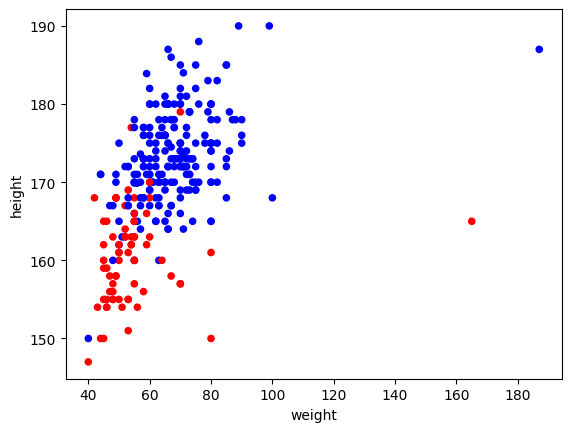

In [ ]:
X_y_train = pd.concat([X_train, y_train], axis=1)

colors = np.where(X_y_train["gender"]==1,'b','-')
colors[X_y_train["gender"]==-1] = 'r'

X_y_train.plot.scatter(y='height', x='weight', c=colors)

In [ ]:
X_train[0:10]
#y_train[0:10]

,id,timestamp,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
285,286,21/12/2017 19:13:36,10,1,170.0,63.0,2,130.0,500.0,6,QQ
180,181,21/12/2017 10:16:14,1,2,156.0,58.0,3,180.0,834.0,0.003,I don't know.
220,221,21/12/2017 10:13:12,5,2,154.0,46.0,5,120.0,70.0,0.01,Optimistic
121,122,20/12/2017 10:06:19,9,2,176.0,72.0,5,120.0,250.0,0.5,I'm so handsome.
211,212,21/12/2017 10:12:19,6,2,179.0,86.0,4,135.0,351.0,0.00015,peace
159,160,21/12/2017 10:12:48,2,2,180.0,66.0,4,180.0,10.0,1,Smart
227,228,21/12/2017 10:13:38,12,1,162.0,54.0,4,110.0,265.0,1,Nice
167,168,21/12/2017 10:13:27,7,1,170.0,63.0,2,144.0,629.0,1.4,a genius of computer science
255,256,21/12/2017 19:12:15,10,2,171.0,73.0,2,87.0,200.0,500,Amazing
196,197,21/12/2017 10:10:54,9,1,171.0,73.0,2,180.0,400.0,2,Handsome


# 4.   Train some ML models on the training set

Next, we are going to apply a machine learning algorithm to the training set, so it's going to "learn" the data. Sometimes we say we are training a ML model here.
Let's use this road map to decide which algorithm we should use: http://scikit-learn.org/stable/tutorial/machine_learning_map/index.html

It suggests us to use Linear Support Vector Machine (SVM).

In [ ]:
from sklearn.svm import LinearSVC
clf = LinearSVC(random_state=0)
clf.fit(numeric_X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(random_state=0)

In [ ]:
predicted_ans = clf.predict(numeric_X_test)
predicted_ans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Average precision-recall score: 0.72


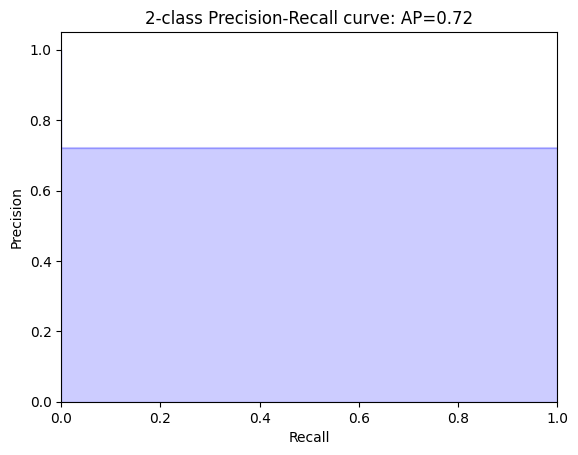

In [ ]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test, predicted_ans)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, predicted_ans)

plt.step(recall, precision, color='b', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='b')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f}'.format(
          average_precision))
plt.show()

In [ ]:
from sklearn.metrics import classification_report
target_names = ['girl', 'boy']
print(classification_report(y_test, predicted_ans, target_names=target_names))

              precision    recall  f1-score   support

        girl       0.00      0.00      0.00        41
         boy       0.72      1.00      0.84       106

    accuracy                           0.72       147
   macro avg       0.36      0.50      0.42       147
weighted avg       0.52      0.72      0.60       147



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier as dtree, export_graphviz
# initiate a Decision Tree with default parameters
dt = dtree()

# train a DT classifier with the training data
dt.fit(numeric_X_train, y_train)


DecisionTreeClassifier()

In [ ]:
predicted_ans = dt.predict(numeric_X_test)

Average precision-recall score: 0.91


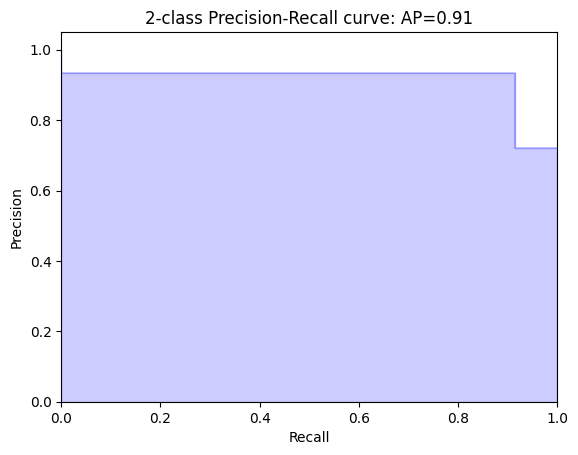

In [ ]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test, predicted_ans)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, predicted_ans)

plt.step(recall, precision, color='b', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='b')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f}'.format(
          average_precision))
plt.show()

In [ ]:
from sklearn.metrics import classification_report
target_names = ['girl', 'boy']
print(classification_report(y_test, predicted_ans, target_names=target_names))
#print(classification_report(y_test, predicted_ans, labels=[1, -1]))

              precision    recall  f1-score   support

        girl       0.79      0.83      0.81        41
         boy       0.93      0.92      0.92       106

    accuracy                           0.89       147
   macro avg       0.86      0.87      0.87       147
weighted avg       0.89      0.89      0.89       147



#Optional: PCA

In [ ]:
'''
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
'''

'\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\n'

In [ ]:
'''
np.random.seed(5)

X = numeric_X_train
y = y_train

fig = plt.figure(1, figsize=(4, 3))
plt.clf()
ax = Axes3D(fig, rect=[0, 0, 0.95, 1], elev=48, azim=134)

plt.cla()
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X = pca.transform(X)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X[y == label, 0].mean(),
        X[y == label, 1].mean() + 1.5,
        X[y == label, 2].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.5, edgecolor="w", facecolor="w"),
    )
# Reorder the labels to have colors matching the cluster results
y = np.choose(y, [1, 2, 0]).astype(float)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.nipy_spectral, edgecolor="k")

ax.w_xaxis.set_ticklabels([])
ax.w_yaxis.set_ticklabels([])
ax.w_zaxis.set_ticklabels([])

plt.show()
'''

'\nnp.random.seed(5)\n\nX = numeric_X_train\ny = y_train\n\nfig = plt.figure(1, figsize=(4, 3))\nplt.clf()\nax = Axes3D(fig, rect=[0, 0, 0.95, 1], elev=48, azim=134)\n\nplt.cla()\npca = decomposition.PCA(n_components=3)\npca.fit(X)\nX = pca.transform(X)\n\nfor name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:\n    ax.text3D(\n        X[y == label, 0].mean(),\n        X[y == label, 1].mean() + 1.5,\n        X[y == label, 2].mean(),\n        name,\n        horizontalalignment="center",\n        bbox=dict(alpha=0.5, edgecolor="w", facecolor="w"),\n    )\n# Reorder the labels to have colors matching the cluster results\ny = np.choose(y, [1, 2, 0]).astype(float)\nax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.nipy_spectral, edgecolor="k")\n\nax.w_xaxis.set_ticklabels([])\nax.w_yaxis.set_ticklabels([])\nax.w_zaxis.set_ticklabels([])\n\nplt.show()\n'

# Optional: Bucketing values into bins

In [ ]:
cleaned_df_bin = coded_df.dropna()

cleaned_df_bin = cleaned_df_bin[(cleaned_df_bin['height']<300) & (cleaned_df_bin['weight']<300) & (cleaned_df_bin['height']>100) & (cleaned_df_bin['fb_friends']<=5000)]

cleaned_df_bin['height'] = pd.cut(cleaned_df_bin['height'], [0,100, 150, 160,170,180,190,200], labels=['0','1','2','3','4','5','6'])
cleaned_df_bin['weight'] = pd.cut(cleaned_df_bin['weight'], [0,40,50,60,70,80,90,100,200], labels=['0','1','2','3','4','5','6','7'])
cleaned_df_bin['iq'] = pd.cut(cleaned_df_bin['iq'], [0,80,90,100,110,120,150,200], labels=['0','1','2','3','4','5','6'])
cleaned_df_bin['fb_friends'] = pd.cut(cleaned_df_bin['fb_friends'], [0,100,200,500,1000,3000,5000], labels=['1','2','3','4','5','6'])

cleaned_df_bin = cleaned_df_bin.dropna()

cleaned_df_bin[0:10]

,id,timestamp,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
0,1,4/7/2017 13:47,-1,8,1,2,1,2,6,4,0,Beautiful
1,2,4/7/2017 13:48,-1,8,1,2,1,2,5,3,3.5,Enjoying being who I'm notsss
2,3,4/7/2017 13:49,1,11,2,3,3,3,1,4,5,Practice Makes perfect
3,4,4/7/2017 13:49,1,11,1,3,3,4,2,2,5,Straightforward
4,5,4/7/2017 13:54,-1,11,2,2,3,3,5,3,1.2,Humorous
5,6,4/7/2017 13:55,-1,12,2,2,1,3,2,4,2,I am cute
6,7,4/7/2017 13:56,1,9,2,3,1,4,4,3,9.59,Homo sapiens
8,9,4/7/2017 13:57,-1,11,2,3,2,2,2,4,5.34,I am quite.
9,10,4/7/2017 14:00,-1,3,1,3,2,5,5,4,2,Beautiful
10,11,4/7/2017 14:01,-1,9,2,3,2,3,6,3,1,Beautiful and smart


In [ ]:
y = cleaned_df_bin.pop('gender') # this is our target label
X = cleaned_df_bin # this is our 'data'

In [ ]:
# carry out random split, where the test (validation) is 33%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
numeric_X_train = X_train.drop(columns=['id','timestamp','self_intro'])
numeric_X_test = X_test.drop(columns=['id','timestamp','self_intro'])

numeric_X_train[0:10]

,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt
447,6,1,4,3,4,4,2,2
215,2,2,4,3,4,6,1,1
400,4,1,3,2,4,1,3,0.1
312,5,1,4,5,5,5,4,0.5
96,8,2,1,7,3,5,2,123
276,7,2,5,4,1,6,3,1
232,2,2,4,2,3,2,1,5
85,8,1,4,3,4,6,3,6
225,12,2,3,1,2,1,1,0
173,9,2,4,2,5,5,2,38


In [ ]:
from sklearn.svm import LinearSVC
clf = LinearSVC(random_state=0)
clf.fit(numeric_X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(random_state=0)

In [ ]:
predicted_ans = clf.predict(numeric_X_test.astype(float))


Average precision-recall score: 0.85


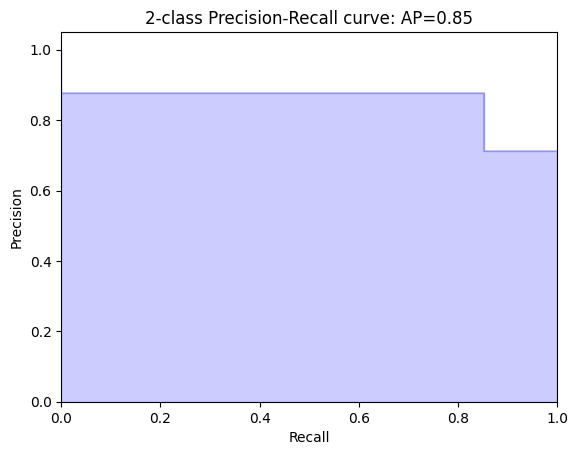

In [ ]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test, predicted_ans)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, predicted_ans)

plt.step(recall, precision, color='b', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='b')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f}'.format(
          average_precision))
plt.show()

In [ ]:
from sklearn.metrics import classification_report
target_names = ['girl', 'boy']
print(classification_report(y_test, predicted_ans, target_names=target_names))

              precision    recall  f1-score   support

        girl       0.66      0.71      0.68        41
         boy       0.88      0.85      0.86       101

    accuracy                           0.81       142
   macro avg       0.77      0.78      0.77       142
weighted avg       0.81      0.81      0.81       142



In [ ]:
from sklearn.tree import DecisionTreeClassifier as dtree, export_graphviz
# initiate a Decision Tree with default parameters
dt = dtree()

# train a DT classifier with the training data
dt.fit(numeric_X_train, y_train)

DecisionTreeClassifier()

In [ ]:
predicted_ans = dt.predict(numeric_X_test)
predicted_ans

array([-1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,
        1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,
        1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,
       -1,  1, -1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1, -1,  1, -1,
        1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,
        1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,
       -1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1, -1, -1,
        1,  1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1, -1,  1,  1])

Average precision-recall score: 0.92


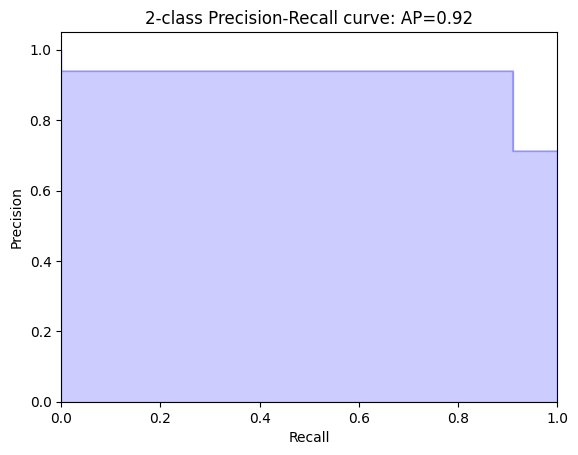

In [ ]:
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(y_test, predicted_ans)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, predicted_ans)

plt.step(recall, precision, color='b', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='b')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('2-class Precision-Recall curve: AP={0:0.2f}'.format(
          average_precision))
plt.show()

In [ ]:
from sklearn.metrics import classification_report
target_names = ['girl', 'boy']
print(classification_report(y_test, predicted_ans, target_names=target_names))

              precision    recall  f1-score   support

        girl       0.80      0.85      0.82        41
         boy       0.94      0.91      0.92       101

    accuracy                           0.89       142
   macro avg       0.87      0.88      0.87       142
weighted avg       0.90      0.89      0.90       142



In [ ]:
'''
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(numeric_X_train, y_train)

predicted_ans = xgb_model.predict(numeric_X_test)
'''



'\nimport xgboost as xgb\nxgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)\nxgb_model.fit(numeric_X_train, y_train)\n\npredicted_ans = xgb_model.predict(numeric_X_test)\n'

# References & Resources


1.   https://www.datasciencecentral.com/profiles/blogs/how-to-treat-missing-values-in-your-data-1
2.   https://towardsdatascience.com/working-with-missing-data-in-machine-learning-9c0a430df4ce
3.   https://towardsdatascience.com/how-to-handle-missing-data-8646b18db0d4
4.   

